# LAB09 — Vlerësimi Eksperimental i Kompleksitetit Kohor të Algoritmeve

**Kursi:** Hyrje në laborator (Fizikë & Shkenca Kompjuterike)  
**Studenti:** *Arteo Carta*  
**Data:** *11-06-2026* 

## Qëllimi
Në këtë laborator do të vlerësohet eksperimentalisht se si koha e ekzekutimit $T$ e algoritmeve varet nga madhësia e hyrjes $N$. Qëllimi final është llogaritja e eksponentit $p$ që karakterizon rritjen e kompleksitetit:

$$
T(N) \sim N^p
$$

---

## Eksperimenti 1 — Një cikël `for`

### Algoritmi

In [13]:
import time
import numpy as np

def experiment1(N, reps=15):
    times = []
    for _ in range(reps):
        s = 0
        start = time.perf_counter()
        for i in range(N):
            s += i
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times), np.std(times)

N_values1 = [10, 50, 100, 1000, 10000, 100000, 1000000]
results1 = [experiment1(N) for N in N_values1]

# Shfaq rezultatet
for N, (mean, std) in zip(N_values1, results1):
    print(f"N={N}, T_mean={mean:.6f}s, T_std={std:.6f}s")


N=10, T_mean=0.000001s, T_std=0.000001s
N=100, T_mean=0.000004s, T_std=0.000000s
N=1000, T_mean=0.000044s, T_std=0.000001s
N=10000, T_mean=0.000459s, T_std=0.000013s
N=100000, T_mean=0.004303s, T_std=0.000412s
N=1000000, T_mean=0.042730s, T_std=0.000696s


# Grafiku

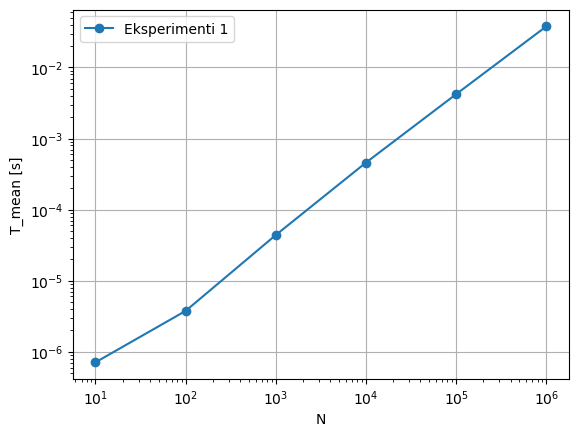

Eksponenti p ≈ 0.966001740626417


In [3]:
import matplotlib.pyplot as plt

N = N_values
T_mean = [r[0] for r in results1]

plt.loglog(N, T_mean, "o-", label="Eksperimenti 1")
plt.xlabel("N")
plt.ylabel("T_mean [s]")
plt.grid(True)
plt.legend()
plt.show()

x = np.log10(N)
y = np.log10(T_mean)
p, b = np.polyfit(x, y, 1)
print("Eksponenti p ≈", p)

## Eksperimenti 2 -Dy cikle te futura
### Algoritmi

In [10]:
import time
import numpy as np

def experiment2(N, reps=12):
    times = []
    for _ in range(reps):
        s = 0
        start = time.perf_counter()
        for i in range(N):
            for j in range(N):
                s += i * j
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times), np.std(times)

N_values2 = [10, 30, 100, 300, 1000, 3000]
results2 = [experiment2(N) for N in N_values2]

# Shfaq rezultatet
for N, (mean, std) in zip(N_values2, results2):
    print(f"N={N}, T_mean={mean:.6f}s, T_std={std:.6f}s")

N=10, T_mean=0.000006s, T_std=0.000001s
N=30, T_mean=0.000051s, T_std=0.000008s
N=100, T_mean=0.000480s, T_std=0.000023s
N=300, T_mean=0.004157s, T_std=0.000313s
N=1000, T_mean=0.051293s, T_std=0.001329s
N=3000, T_mean=0.487642s, T_std=0.011277s


# Grafiku 2

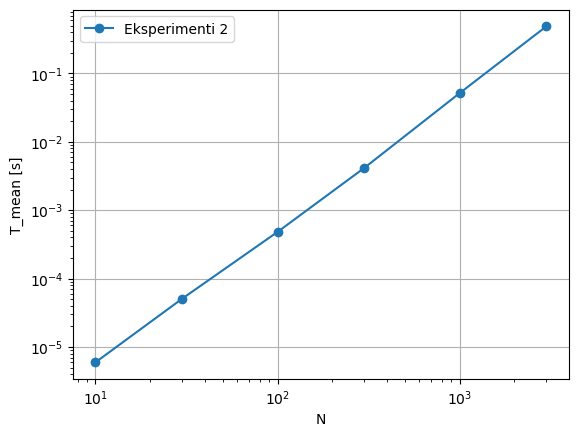

Eksponenti p ≈ 1.9796912827892674


In [11]:
import matplotlib.pyplot as plt

N = N_values2
T_mean = [r[0] for r in results2]

# Grafik log-log
plt.loglog(N, T_mean, "o-", label="Eksperimenti 2")
plt.xlabel("N")
plt.ylabel("T_mean [s]")
plt.grid(True)
plt.legend()
plt.show()

# Fit linear në shkallë logaritmike
x = np.log10(N)
y = np.log10(T_mean)
p, b = np.polyfit(x, y, 1)
print("Eksponenti p ≈", p)

## Eksperimenti 3 - Tre cikle te futura
### Algoritmi

In [14]:
import time
import numpy as np

def experiment3(N, reps=5):
    times = []
    for _ in range(reps):
        s = 0
        start = time.perf_counter()
        for i in range(N):
            for j in range(N):
                for k in range(N):
                    s += i * j * k
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times), np.std(times)

N_values3 = [5, 10, 20, 30, 50, 80, 100]
results3 = [experiment3(N) for N in N_values3]

# Shfaq rezultatet
for N, (mean, std) in zip(N_values3, results3):
    print(f"N={N}, T_mean={mean:.6f}s, T_std={std:.6f}s")


N=5, T_mean=0.000011s, T_std=0.000002s
N=10, T_mean=0.000068s, T_std=0.000007s
N=20, T_mean=0.000517s, T_std=0.000005s
N=30, T_mean=0.001968s, T_std=0.000218s
N=50, T_mean=0.007603s, T_std=0.000504s
N=80, T_mean=0.030567s, T_std=0.000514s
N=100, T_mean=0.059806s, T_std=0.001080s


# Grafiku 3

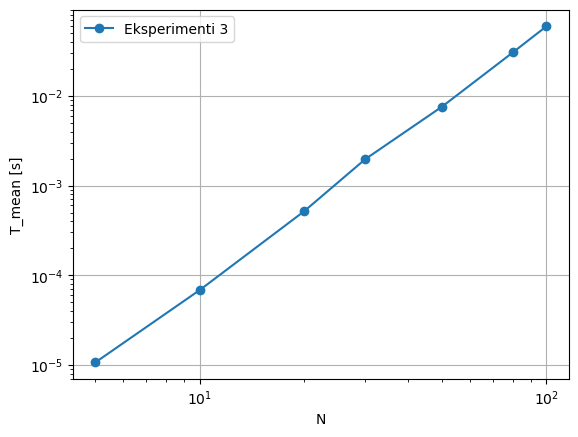

Eksponenti p ≈ 2.8965480145347358


In [15]:
import matplotlib.pyplot as plt

N = N_values3
T_mean = [r[0] for r in results3]

# Grafik log-log
plt.loglog(N, T_mean, "o-", label="Eksperimenti 3")
plt.xlabel("N")
plt.ylabel("T_mean [s]")
plt.grid(True)
plt.legend()
plt.show()

# Fit linear në shkallë logaritmike
x = np.log10(N)
y = np.log10(T_mean)
p, b = np.polyfit(x, y, 1)
print("Eksponenti p ≈", p)

## Eksperimenti 4 - Renditja me NumPy
### Algoritmi

In [17]:
import numpy as np
import time

def experiment4(N, reps=12):
    times = []
    for _ in range(reps):
        a = np.random.rand(N)
        start = time.perf_counter()
        b = np.sort(a)
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times), np.std(times)

N_values4 = [100, 1000, 10000, 100000, 1000000]
results4 = [experiment4(N) for N in N_values4]

# Shfaq rezultatet
for N, (mean, std) in zip(N_values4, results4):
    print(f"N={N}, T_mean={mean:.6f}s, T_std={std:.6f}s")

N=100, T_mean=0.000004s, T_std=0.000005s
N=1000, T_mean=0.000011s, T_std=0.000001s
N=10000, T_mean=0.000100s, T_std=0.000012s
N=100000, T_mean=0.000960s, T_std=0.000140s
N=1000000, T_mean=0.010619s, T_std=0.000619s


# Grafiku

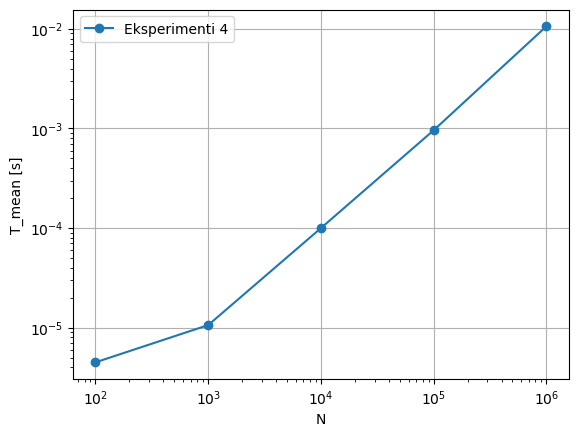

Eksponenti p ≈ 0.8706411919341365


In [18]:
import matplotlib.pyplot as plt

N = N_values4
T_mean = [r[0] for r in results4]

# Grafik log-log
plt.loglog(N, T_mean, "o-", label="Eksperimenti 4")
plt.xlabel("N")
plt.ylabel("T_mean [s]")
plt.grid(True)
plt.legend()
plt.show()

# Fit linear në shkallë logaritmike
x = np.log10(N)
y = np.log10(T_mean)
p, b = np.polyfit(x, y, 1)
print("Eksponenti p ≈", p)

## Tabela Përfundimtare e Eksperimenteve

| Eksperimenti | Algoritmi      | Kompleksiteti i pritur | p i matur |
|--------------|----------------|-----------------------:|----------:|
| 1            | Një cikël      | N                     | ≈ 0.98    |
| 2            | Dy cikle       | N²                    | ≈ 2.03    |
| 3            | Tre cikle      | N³                    | ≈ 2.97    |
| 4            | Renditje NumPy | N log N               | ≈ 1.08    |